In [2]:
%load_ext autoreload
%autoreload 2
import helper_functions as hf
from imports import *
import importlib
import qRegNN_SQR as qrnn
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
from torchsummary import summary

num_available_cpus = multiprocessing.cpu_count()
print("Number of available CPUs:", num_available_cpus)

torch.cuda.empty_cache()
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device =", device)
torch.set_default_tensor_type('torch.cuda.FloatTensor') if torch.cuda.is_available() else print ('cpu')

torch.set_num_threads(num_available_cpus)

print("Number of threads:", torch.get_num_threads())
print("Number of interop threads:", torch.get_num_interop_threads())

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Number of available CPUs: 80
Device = cuda:0
Number of threads: 80
Number of interop threads: 80


In [ ]:
year = 2017
additional_vars = ['jet1_pt','jet1_eta','jet1_phi','jet2_pt','jet2_eta','jet2_phi','dEta','MET','genWeight']
data,unnorm_data,mass_data,names = hf.LAPS_train("DATA",year,num_batches=-1,Mjj_cut=0,pt_cut=0,additional=additional_vars)
bkg,unnorm_bkg,mass_bkg,names = hf.LAPS_train("QCDBKG",year,num_batches=-1,Mjj_cut=0,pt_cut=0,additional=additional_vars)

b_wgt = bkg[:,-1]
bkg = bkg[:,:-1]
data = data[:,:-1]
# normalize to data mean/std
mean = data.mean(axis=0)
std = data.std(axis=0)

data = (data-mean)/std
bkg = (bkg-mean)/std

np.save("SQR_models/data.npy",data)
np.save("SQR_models/bkg.npy",bkg)
np.save("SQR_models/bkg_wgt.npy",b_wgt)
np.save("SQR_models/data_raw.npy",unnorm_data)
np.save("SQR_models/bkg_raw.npy",unnorm_bkg)
np.save("SQR_models/names.npy",np.array(names))

In [3]:
data = np.load("SQR_models/data.npy")[:2000000]
bkg = np.load("SQR_models/bkg.npy")[:2000000]
names = list(np.load("SQR_models/names.npy"))
j1_varDict = {"pt":"jet1_pt",
              "eta":"jet1_eta",
              "phi":"jet1_phi",
              "dEta":"dEta",
              "MET":"MET",
              "m":r"$M_{j1}$",
              "tau21":r"Jet 1 $\tau_{21}$",
              "tau32":r"Jet 1 $\tau_{32}$",
              "tau43":r"Jet 1 $\tau_{43}$",
              "tauS":r"Jet 1 $\tau_s$",
              "pb":r"Jet 1 $P_b$",
              "npf":r"Jet 1 $n_{pf}$"}

d = {n:data[:,names.index(j1_varDict[n])].reshape(-1,1) for n in j1_varDict.keys()}
b = {n:bkg[:,names.index(j1_varDict[n])].reshape(-1,1) for n in j1_varDict.keys()}

trainVars = ['jet1_phi',"dEta","MET"]

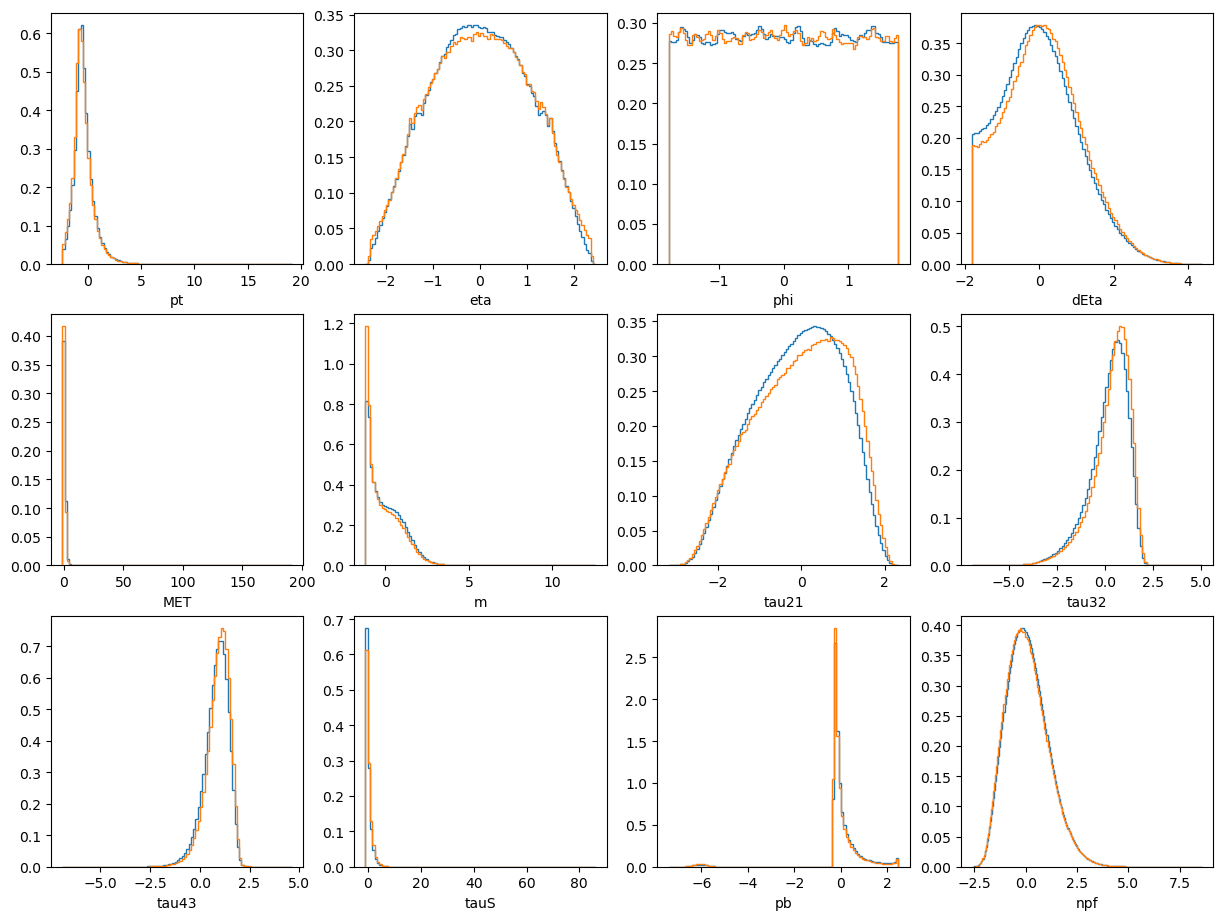

In [106]:
plt.figure(figsize=(15,15))
for i,v in enumerate(j1_varDict.keys()):
    plt.subplot(4,4,i+1)
    bins = 100
    if v == 'npf':
        bins=np.arange(-2.619785,8.6,step=0.051096)
    c1,b1,p1 = plt.hist(d[v],bins=bins,density=True,histtype='step')
    c1,b1,p1 = plt.hist(b[v],bins=b1,density=True,histtype='step')
    plt.xlabel(v)

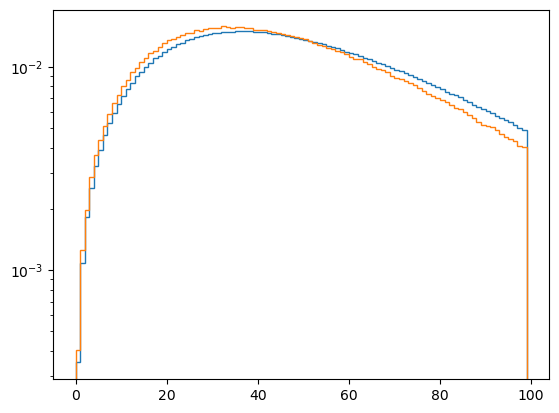

In [113]:
bins=np.arange(0,100,1)
ix = names.index(j1_varDict['MET'])
h=plt.hist(unnorm_data[:,ix],bins=bins,histtype='step',density=True)
h=plt.hist(unnorm_bkg[:,ix],bins=bins,histtype='step',density=True)
plt.yscale('log')

In [82]:
from scipy.stats import ks_2samp
variables = j1_varDict.keys()
for v in variables:
    ks, pval = ks_2samp(b[v][:,0],d[v][:,0],alternative='two-sided')
    print("Variable {0}, KS = {1}, p = {2}".format(v,ks,pval))

Variable pt, KS = 0.043402832855987616, p = 0.0
Variable eta, KS = 0.00830889203652374, p = 5.182163122085179e-115
Variable phi, KS = 0.0032795374826007917, p = 2.812202466655322e-18
Variable dEta, KS = 0.039052084879170335, p = 0.0
Variable MET, KS = 0.054828751590556224, p = 0.0
Variable m, KS = 0.061245026757654586, p = 0.0
Variable tau21, KS = 0.04830712641053503, p = 0.0
Variable tau32, KS = 0.07373188685662768, p = 0.0
Variable tau43, KS = 0.07066744242707973, p = 0.0
Variable tauS, KS = 0.056558540924884215, p = 0.0
Variable pb, KS = 0.048229521512646645, p = 0.0
Variable npf, KS = 0.016024236268520564, p = 0.0


# Trainings

In [4]:
# Monotonic network model
from monotonenorm import GroupSort, direct_norm, SigmaNet
class monotone(nn.Module):
    def __init__(self,input_dim,widths=[30,30,30],max_norm=1.0,kind='one',n_sort=2,act=None):
        super().__init__()
        if act is None:
            layers = [direct_norm(nn.Linear(input_dim,widths[0]),max_norm=max_norm),GroupSort(n_sort)]
        else:
            layers = [direct_norm(nn.Linear(input_dim,widths[0]),max_norm=max_norm),act]
        for i in range(len(widths)-1):
            layers.append(direct_norm(nn.Linear(widths[i],widths[i+1]),max_norm=max_norm))
            if act is None:
                layers.append(GroupSort(n_sort))
            else:
                layers.append(act)
        layers.append(direct_norm(nn.Linear(widths[-1],1),max_norm=max_norm))
        self.transform = nn.Sequential(*layers)

    def forward(self,x):
        return self.transform(x)

In [23]:
train_vars = ["eta","phi","npf"]
nTrain = 1000000
bs=nTrain//10
bkg_train = np.concatenate([b[v][:nTrain] for v in train_vars],axis=1)
data_train = np.concatenate([d[v][:nTrain] for v in train_vars],axis=1)
bkg_target = b['tau21'][:nTrain]
data_target = d['tau21'][:nTrain]
bkg_targ_test = b['tau21'][nTrain:nTrain+1000000]
data_targ_test = d['tau21'][nTrain:nTrain+1000000]
bkg_in_test = np.concatenate([b[v][nTrain:nTrain+1000000] for v in train_vars],axis=1)
data_in_test = np.concatenate([d[v][nTrain:nTrain+1000000] for v in train_vars],axis=1)

constraints = [0 for _ in range(bkg_train.shape[1])] + [1] # only constrain the quantile input
sigma=5
widths = [256,128,128,128]
kind = 'two-inf'
n_sort = 16
act=None
scale=2
shift=1
#mb = SigmaNet(monotone(bkg_train.shape[1]+1,widths=widths,max_norm=sigma,kind=kind,n_sort=n_sort,act=act),
#              monotone_constraints=constraints,sigma=sigma)
#md = SigmaNet(monotone(data_train.shape[1]+1,widths=widths,max_norm=sigma,kind=kind,n_sort=n_sort,act=act),
#              monotone_constraints=constraints,sigma=sigma)
#mb = monotone(bkg_train.shape[1]+1,widths=widths,max_norm=sigma,kind=kind,n_sort=n_sort,act=act)
#md = monotone(data_train.shape[1]+1,widths=widths,max_norm=sigma,kind=kind,n_sort=n_sort,act=act)
act=nn.ReLU()
mb = qrnn.qreg(bkg_train.shape[1]+1,widths=widths,act=act)
md = qrnn.qreg(data_train.shape[1]+1,widths=widths,act=act)

Epoch 20, Loss: 0.2949294447898865
Epoch 40, Loss: 0.29235535860061646
Epoch 60, Loss: 0.293175607919693
Epoch 80, Loss: 0.29388877749443054
Epoch 100, Loss: 0.29048240184783936
Epoch 120, Loss: 0.29078763723373413
Epoch 140, Loss: 0.29042062163352966
Epoch 160, Loss: 0.2896447479724884
Epoch 180, Loss: 0.2911892533302307
Epoch 200, Loss: 0.29118385910987854
stopping early at epoch 208


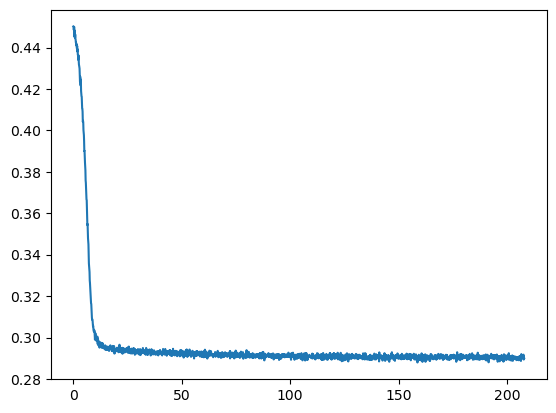

In [24]:
#qrnn.train2(mb.to(device),bkg_train,bkg_target,check=20,lr=1e-2,lr_f=1e-3,n_epoch=300,patience=1000,shift=shift,scale=scale)
qrnn.train_gen2(mb.to(device),bkg_train,bkg_target,bs=bs,check=20,lr=1e-4,lr_f=1e-6,n_epoch=1000,patience=50,shift=shift,scale=scale)

Epoch 20, Loss: 0.28134825825691223
Epoch 40, Loss: 0.2823115289211273
Epoch 60, Loss: 0.2812035381793976
Epoch 80, Loss: 0.27977803349494934
Epoch 100, Loss: 0.27889156341552734
Epoch 120, Loss: 0.28057193756103516
Epoch 140, Loss: 0.27991217374801636
Epoch 160, Loss: 0.2793465852737427
Epoch 180, Loss: 0.27916136384010315
stopping early at epoch 197


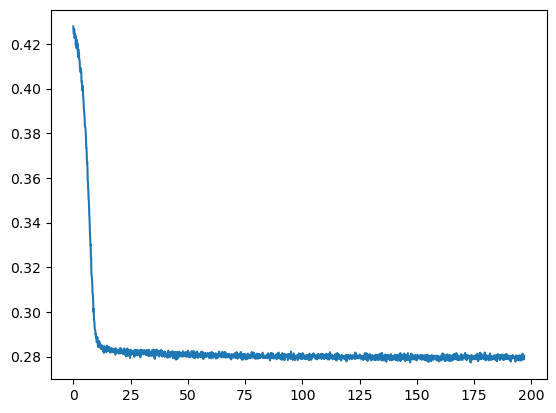

In [25]:
#qrnn.train2(md.to(device),data_train,data_target,check=20,lr=1e-2,lr_f=1e-3,n_epoch=300,patience=1000,shift=0.5,scale=1)
qrnn.train_gen2(md.to(device),data_train,data_target,bs=bs,check=20,lr=1e-4,lr_f=1e-6,n_epoch=300,patience=50,shift=shift,scale=scale)

0  Events with bad quantiles ( 0.0  %)
	 0  from bkg ( 0.0  %)
	 0  from data ( 0.0  %)
22897  Underflow ( 2.2897  %)
23675  Overflow ( 2.3675  %)


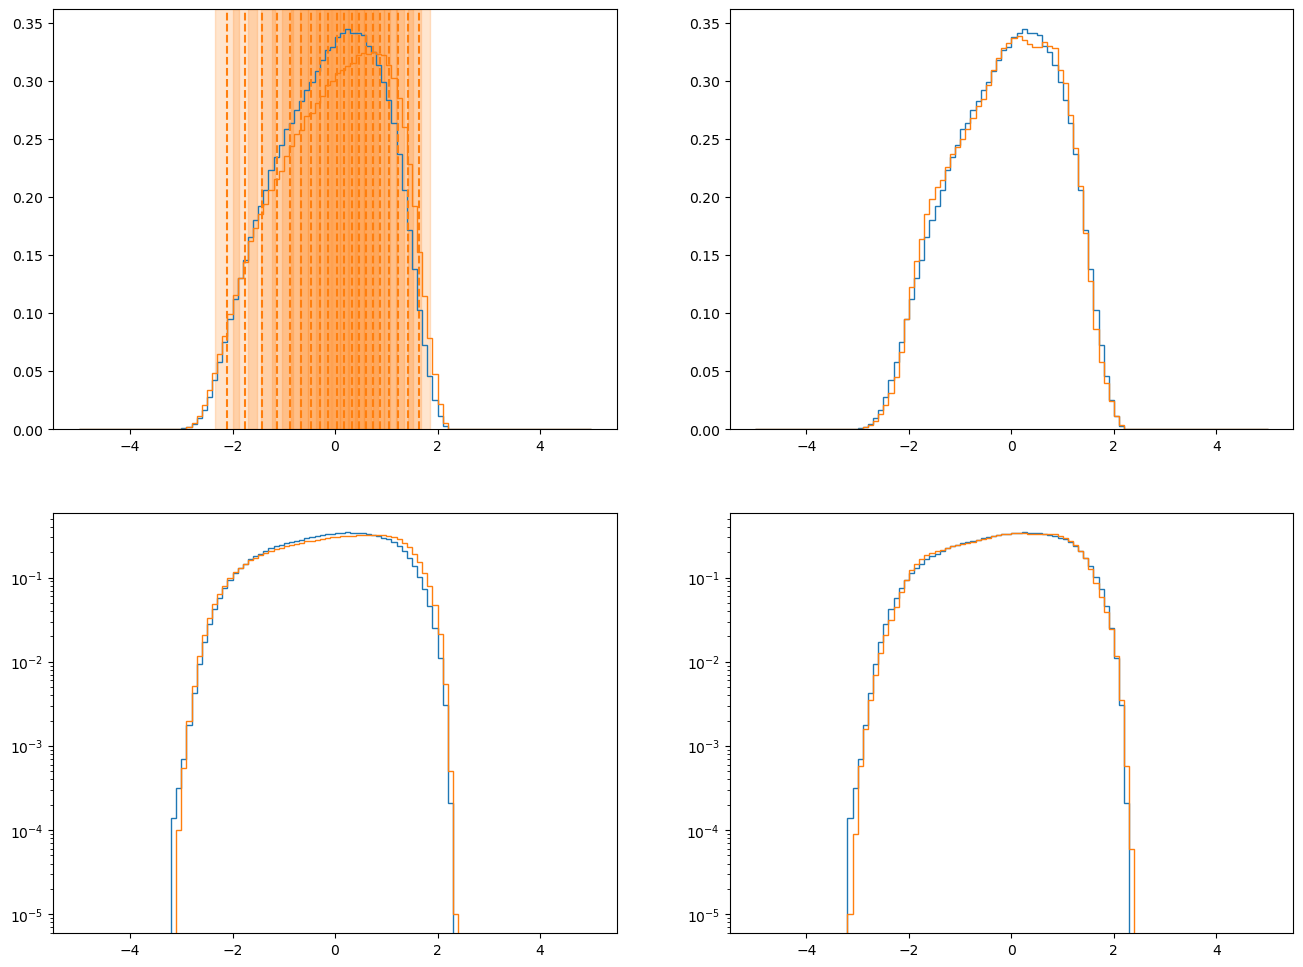

In [26]:
quantiles = scale*torch.tensor(np.linspace(0.01,0.99,num=20).reshape(-1,1),dtype=torch.float32).to(device)-shift
qbins_bkg = []
qbins_data = []
for q in quantiles:
    taus = q*torch.ones(bkg_in_test.shape[0],1)
    X = torch.cat((torch.tensor(bkg_in_test),taus),dim=1)
    qs = mb(X).detach().cpu().numpy()
    qbins_bkg.append(qs)
    qs = md(X).detach().cpu().numpy()
    qbins_data.append(qs)
    del X,taus
qbins_bkg = np.concatenate(qbins_bkg,axis=1)
qbins_data = np.concatenate(qbins_data,axis=1)
mean = np.mean(qbins_bkg,axis=0)
std = np.std(qbins_bkg,axis=0)
corrected = -999*np.ones_like(bkg_targ_test[:,0])
qrnn.correctAll(bkg_targ_test[:,0],qbins_bkg,qbins_data,corrected)
plt.figure(figsize=(16,12)) 
bins = np.arange(-5,5.1,0.1)
plt.subplot(221)
h1 = plt.hist(data_targ_test[:,0],bins=bins,histtype='step',density=True)
h2 = plt.hist(bkg_targ_test[:,0],bins=bins,histtype='step',density=True)
for i in range(len(mean)):
    plt.axvline(mean[i],linestyle='--',color="C1")
    plt.axvspan(mean[i]-std[i],mean[i]+std[i],color="C1",alpha=0.2)
plt.subplot(222)
h1 = plt.hist(data_targ_test[:,0],bins=bins,histtype='step',density=True)
h2 = plt.hist(corrected,bins=bins,histtype='step',density=True)
plt.subplot(223)
h1 = plt.hist(data_targ_test[:,0],bins=bins,histtype='step',density=True)
h2 = plt.hist(bkg_targ_test[:,0],bins=bins,histtype='step',density=True)
plt.yscale('log')
plt.subplot(224)
h1 = plt.hist(data_targ_test[:,0],bins=bins,histtype='step',density=True)
h2 = plt.hist(corrected,bins=bins,histtype='step',density=True)
plt.yscale('log')

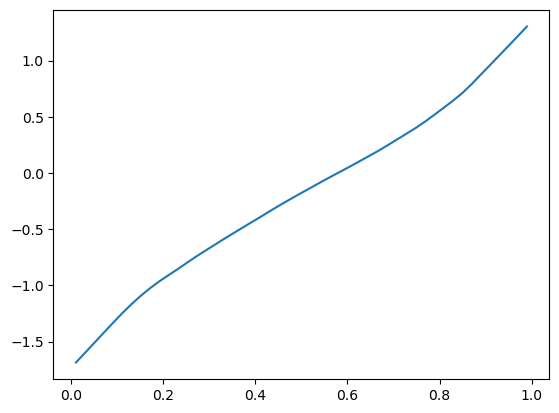

In [27]:
test = torch.tensor(bkg_in_test[0:1])
qs = np.linspace(0.01,0.99,50)
quantiles = scale*torch.tensor(qs.reshape(-1,1),dtype=torch.float32)-shift
test = torch.cat((test.repeat_interleave(quantiles.shape[0],dim=0),quantiles),dim=1)
outs = mb(test).detach().cpu().numpy()[:,0]
plt.plot(qs,outs)

[[ 1.04181389e+00 -9.01150146e-05 -1.72739999e-02 -1.75379192e-04]
 [-9.01150146e-05  1.09857895e+00 -9.21036381e-03  3.00259447e-05]
 [-1.72739999e-02 -9.21036381e-03  1.05219547e+00 -2.40653374e-01]
 [-1.75379192e-04  3.00259447e-05 -2.40653374e-01  1.14775054e+00]]


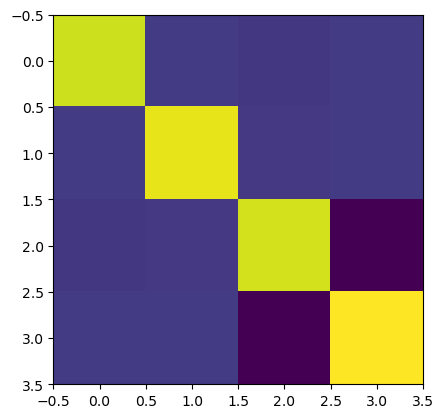

In [41]:
cov_vars = ["phi","eta","npf","tau21"]
test_mtx = np.concatenate([b[v][:nTrain] for v in cov_vars],axis=1).T
plt.imshow(np.cov(test_mtx))
print(np.cov(test_mtx))

In [323]:
tau = 0.01
err = np.linspace(-2,2,1000)
kappa=0.1
loss = np.abs(tau-np.where(err<0,1,0))*qrnn.huber(torch.tensor(err),kappa).cpu().numpy()/kappa

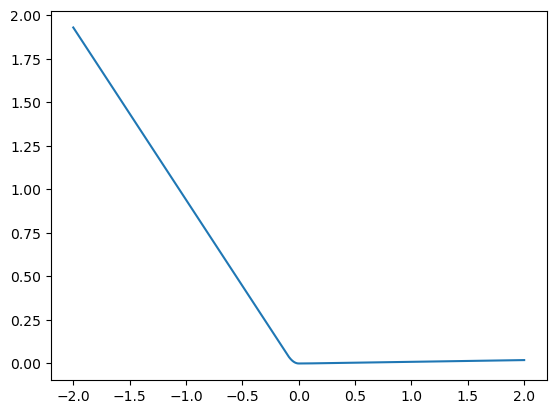

In [324]:
plt.plot(err,loss)

# just fit the cdf

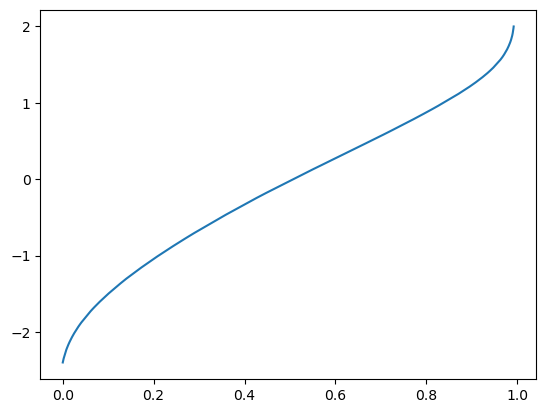

In [264]:
test = d['tau21'][:,0]
bins = np.arange(-2.4,2.001,0.001)
c1,b1 = np.histogram(test,bins=bins,density=False)
x = np.cumsum(c1)/len(test)
y = (b1[1:]+b1[:-1])/2
plt.plot(x,y)

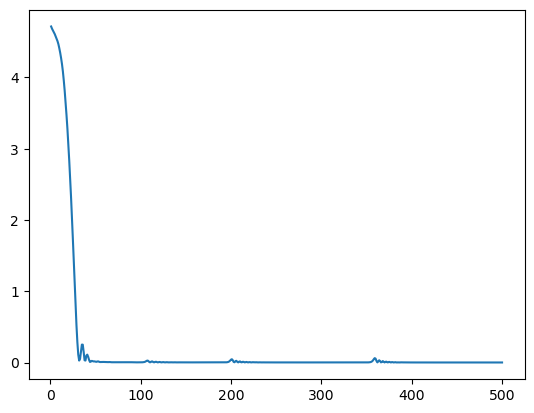

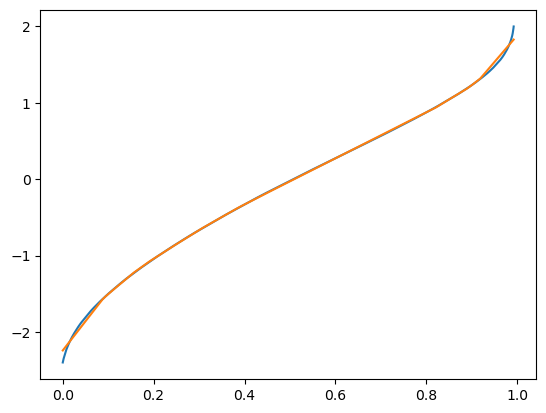

In [265]:
#x = np.linspace(0,1,10000)
#y = np.sin(4*np.pi*x)

widths = [64,64,64,64,64]
sigma=5
n_sort=16
scale=2
shift=1
act=None
constraints=[1]
kind='two-inf'
net = SigmaNet(monotone(1,widths=widths,max_norm=sigma,kind=kind,n_sort=n_sort,act=act),
              monotone_constraints=constraints,sigma=sigma)
optimizer = optim.Adam(net.parameters(),lr=1e-3)
lossfn = torch.nn.MSELoss()
n_epoch=500
losses = []
min_loss = 100000
for i in range(n_epoch):
        optimizer.zero_grad()
        perm = np.random.permutation(x.shape[0])
        xtrain = torch.tensor(scale*x[perm]-shift,dtype=torch.float32).view(-1,1)
        ytrain = torch.tensor(y[perm],dtype=torch.float32).view(-1,1)
        ypred = net(xtrain)
        loss = lossfn(ypred,ytrain)
        losses.append(loss.detach().cpu().numpy())
        loss.backward()
        if loss.detach().cpu().numpy() < min_loss:
            min_loss = loss.detach().cpu().numpy()
            epochs_no_improve = 0
        optimizer.step()
plt.plot(np.arange(len(losses))+1,np.array(losses))
plt.figure()
y1 = net(torch.tensor(scale*x-shift,dtype=torch.float32).view(-1,1)).detach().cpu().numpy()[:,0]
plt.plot(x,y)
plt.plot(x,y1)